### Framing the problem statement

Assist in detecting scam job posting before users see them

#### Problem Statement

Build a system that can automatically identify potentially fradulent job postings early so they can be flagged for manual review before being shown to job seekers.



### Dataset Audit

#### Step 1: Inspecting dataset structure and column types

In [106]:
import pandas as pd

df = pd.read_csv("DataSet.csv")

df.shape #(17880, 18) - 17,880 job postings, 18 attributes per job posting
df.columns #to see the metadata
# Target Variable: fraudulent

df.info()
# there's a need to change some variables to binary numeric values
# fraudulent
# has_company_logo
# has_questions
# in_balanced_dataset
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                17880 non-null  str  
 1   location             17534 non-null  str  
 2   department           6333 non-null   str  
 3   salary_range         2868 non-null   str  
 4   company_profile      14572 non-null  str  
 5   description          17880 non-null  str  
 6   requirements         15191 non-null  str  
 7   benefits             10684 non-null  str  
 8   telecommuting        17880 non-null  str  
 9   has_company_logo     17880 non-null  str  
 10  has_questions        17880 non-null  str  
 11  employment_type      14409 non-null  str  
 12  required_experience  10830 non-null  str  
 13  required_education   9775 non-null   str  
 14  industry             12977 non-null  str  
 15  function             11425 non-null  str  
 16  fraudulent           17880 non-nu

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,in_balanced_dataset
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"<h3>We're Food52, and we've created a groundbr...","<p>Food52, a fast-growing, James Beard Award-w...",<ul>\r\n<li>Experience with content management...,NaN,f,t,f,Other,Internship,NaN,NaN,Marketing,f,f
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"<h3>90 Seconds, the worlds Cloud Video Product...",<p>Organised - Focused - Vibrant - Awesome!<br...,<p><b>What we expect from you:</b></p>\r\n<p>Y...,<h3><b>What you will get from us</b></h3>\r\n<...,f,t,f,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,f,f
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,<h3></h3>\r\n<p>Valor Services provides Workfo...,"<p>Our client, located in Houston, is actively...",<ul>\r\n<li>Implement pre-commissioning and co...,NaN,f,t,f,NaN,NaN,NaN,NaN,NaN,f,f
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,<p>Our passion for improving quality of life t...,<p><b>THE COMPANY: ESRI – Environmental System...,<ul>\r\n<li>\r\n<b>EDUCATION: </b>Bachelor’s o...,<p>Our culture is anything but corporate—we ha...,f,t,f,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,f,f
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,<p>SpotSource Solutions LLC is a Global Human ...,<p><b>JOB TITLE:</b> Itemization Review Manage...,<p><b>QUALIFICATIONS:</b></p>\r\n<ul>\r\n<li>R...,<p>Full Benefits Offered</p>,f,t,t,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,f,f


The dataset consists of 17,880 job advertisements, each described by 18 attributes. These attributes fall into distinct categories, and the metadata helps clarify their roles in the analysis. The primary outcome of interest is whether a posting is fraudulent, so fraudulent is set as the target variable. Several variables that are conceptually binary are currently stored as strings and should be converted to numeric form before analysis. A more detailed examination of the target variable distribution will be performed later to understand how fraud labels are distributed across the dataset.

It is important to take note of the 'in_balanced_dataset' which may be added by the dataset authors, using it during training would cause data leakage. This variable should be excluded from modelling

#### Step 2 - Missing value analysis

In [107]:
# Compute missing counts and percentages per column
missing_counts = df.isna().sum()
missing_percentage = df.isna().mean() * 100

missing_summary = (
    pd.DataFrame({
        "missing_count": missing_counts,
        "missing_pct": missing_pct.round(2),
    })
    .sort_values("missing_pct", ascending=False)
)

missing_summary

,missing_count,missing_pct
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7196,40.25
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2689,15.04


A high percentage of data is missing when it comes to salary_range and department. We cannot rely on them as raw features. 
There are sustantial amounts of missing data in required_education, benefits, required_experience, function, industry, employment_type, company_profile, requirements. It is still, however potentially useful but with care. Over here, missingness itself may be informative as scams might skip company profile or benefits. We can see whether these missingness may be related to fraud later on

The following variables are almost fully observed:

title, description, telecommuting, has_company_logo, has_questions, fraudulent, in_balanced_dataset all have 0% missing which are reliable

In [108]:
# Compare fraud rate when company_profile is missing vs present
df["company_profile_missing"] = df["company_profile"].isna().astype(int)

pd.crosstab(
    df["company_profile_missing"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,f,t
company_profile_missing,,
0,0.980854,0.019146
1,0.822551,0.177449


- With profile (0): about 1.9% of postings are fraudulent 

- Without profile (1): about 17.7% of postings are fraudulent

Jobs that omit a company profile are roughly 9 times more likely to be labeled fraudulent than those that include one. This might be a strong pattern between "missing company profile" and fraudulent job posting.

In [109]:
# Compare fraud rate when requirements is missing vs present
df["requirements_missing"] = df["requirements"].isna().astype(int)

pd.crosstab(
    df["requirements_missing"],
    df["fraudulent"],
    normalize="index"
)

fraudulent,f,t
requirements_missing,,
0,0.953064,0.046936
1,0.943102,0.056898


- With requirements (0): about 4% of postings are fraudulent 

- Without requirements (1): about 5% of postings are fraudulent

Not much pattern between "missing requirements" and fraudulent job posting.

#### Step 3: Targetting class imbalance (fraudulent vs legitimate)

In [110]:
class_counts = df['fraudulent'].value_counts()
class_percentage = df['fraudulent'].value_counts(normalize=True)

class_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentage.round(2),
})

class_summary

,count,percentage
fraudulent,,
f,17014,0.95
t,866,0.05


We can see that the dataset is highly imbalanced, with fraudulent posting representing only around 5% of the data. We should avoid using accuracy alone and instead focus on metrics like precision, recall, F1, and PR-AUC, and consider techniques that handle this class imbalance.

### Exploratory Data Analysis

Changing the fraudulent response variable to binary 
- 0: legitmate
- 1: fraudulent

In [111]:
df["fraudulent"].value_counts(dropna=False)

df["fraudulent"] = (
    df["fraudulent"]
    .astype(str)      # ensure string
    .str.strip()      # remove any spaces
    .map({"f": 0, "t": 1})
    .astype(int)      # now safe; no NAs expected
)

df["fraudulent"].value_counts(dropna=False), df["fraudulent"].dtype

(fraudulent
 0    17014
 1      866
 Name: count, dtype: int64,
 dtype('int64'))

#### Text length features and their relation to fraud

In [112]:
# Length features
df["description_len"] = df["description"].str.len()
df["requirements_len"] = df["requirements"].fillna("").str.len()
df["company_profile_len"] = df["company_profile"].fillna("").str.len()

df[["description_len", "requirements_len", "company_profile_len"]].describe()

,description_len,requirements_len,company_profile_len
count,17880.000000,17880.000000,17880.000000
mean,1438.563423,731.389597,693.798098
std,1715.209068,1254.239918,649.098339
min,10.000000,0.000000,0.000000
25%,676.000000,183.000000,152.000000
50%,1158.000000,564.000000,614.000000
75%,1775.250000,971.000000,965.000000
max,55130.000000,37994.000000,6450.000000


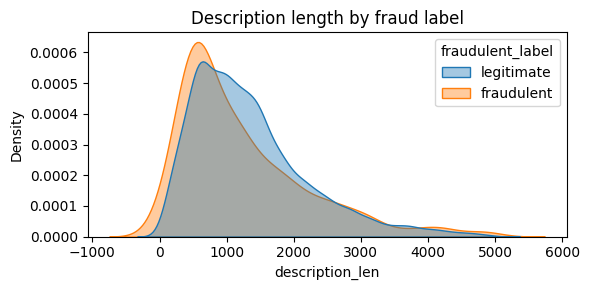

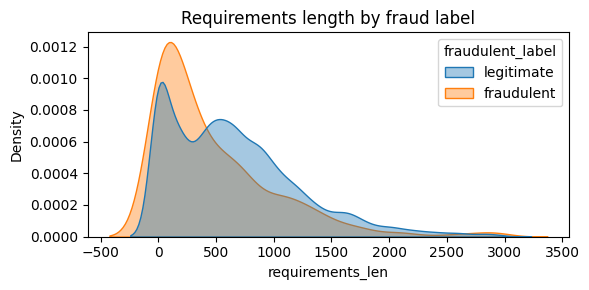

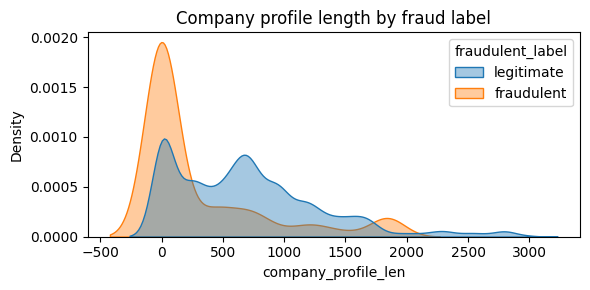

In [113]:
# Helper function using human‑readable fraud label
df["fraudulent_label"] = df["fraudulent"].map({0: "legitimate", 1: "fraudulent"})

def plot_length_by_fraud(col, title, max_len=None):
    subset = df.copy()
    if max_len is not None:
        subset = subset[subset[col] <= max_len]

    subset = subset.dropna(subset=[col, "fraudulent_label"])

    plt.figure(figsize=(6, 3))
    sns.kdeplot(
        data=subset,
        x=col,
        hue="fraudulent_label",
        common_norm=False,
        fill=True,
        alpha=0.4,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_length_by_fraud("description_len", "Description length by fraud label", max_len=5000)
plot_length_by_fraud("requirements_len", "Requirements length by fraud label", max_len=3000)
plot_length_by_fraud("company_profile_len", "Company profile length by fraud label", max_len=3000)

- Description length vs fraud
    - Both legitimate and fraudulent ads have similar description lengths, but fraudulent ads are slightly shorter on average (their peak is a bit left of legitimate).
    - Takeaway: description length has some signal (very short descriptions are more suspicious) but there is substantial overlap, so it’s a weak feature on its own.

- Requirements length vs fraud

    - Fraudulent ads have noticeably shorter requirements sections; the orange peak is concentrated at low lengths, while legitimate ads extend further into longer requirements.
    - Takeaway: scammers tend to provide few or vague requirements, so “short or missing requirements” is a moderate fraud indicator.

- Company profile length vs fraud

    - Fraudulent ads cluster very strongly at near‑zero company profile length, while legitimate ads show much longer and more varied company profiles
    - Takeaway: a missing or extremely short company profile is a strong signal of fraud, consistent with your earlier missing‑value analysis.

In [114]:
missing_cols = ["company_profile", "requirements", "benefits", "salary_range"]

for col in missing_cols:
    miss_flag = col + "_missing"
    df[miss_flag] = df[col].isna().astype(int)
    print(f"\nFraud rate by {miss_flag}:")
    display(
        df.groupby(miss_flag)["fraudulent"]
        .mean()
        .reset_index(name="fraud_rate")
    )


Fraud rate by company_profile_missing:


,company_profile_missing,fraud_rate
0,0,0.019146
1,1,0.177449



Fraud rate by requirements_missing:


,requirements_missing,fraud_rate
0,0,0.046936
1,1,0.056898



Fraud rate by benefits_missing:


,benefits_missing,fraud_rate
0,0,0.047080
1,1,0.050445



Fraud rate by salary_range_missing:


,salary_range_missing,fraud_rate
0,0,0.077755
1,1,0.042832


The fraud rate when company profile is missing is the highest at 17.7% compared to requirements, benefits or salary range missing, confirming the hypothesis

,employment_type,fraud_rate
3,Part-time,0.092848
2,Other,0.066079
1,Full-time,0.042169
0,Contract,0.028871
4,Temporary,0.008299


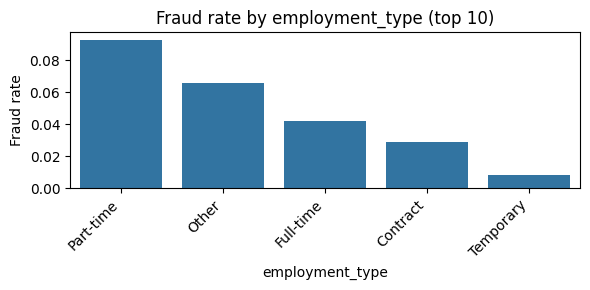

In [115]:
# Look at most common employment types and their fraud rates
emp_ct = (
    df["employment_type"]
    .value_counts()
    .head(10)
    .index
)

emp_summary = (
    df[df["employment_type"].isin(emp_ct)]
    .groupby("employment_type")["fraudulent"]
    .mean()
    .reset_index(name="fraud_rate")
    .sort_values("fraud_rate", ascending=False)
)

display(emp_summary)

plt.figure(figsize=(6, 3))
sns.barplot(
    data=emp_summary,
    x="employment_type",
    y="fraud_rate"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraud rate")
plt.title("Fraud rate by employment_type (top 10)")
plt.tight_layout()
plt.show()

- Fraud rate by employment type

    - Fraud rates are highest for part‑time and “Other” roles, lower for full‑time and contract, and very low for temporary roles.
    - Takeaway: scammers are more likely to position jobs as part‑time / ambiguous employment type, so employment type is a useful categorical feature, though less decisive than company profile completeness

In [116]:
# Convert other binary flags to 0/1
binary_cols = ["telecommuting", "has_company_logo", "has_questions", "in_balanced_dataset"]

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .map({"f": 0, "t": 1})
        .astype(int)
    )

# Human‑readable label for plotting/summary
df["fraudulent_label"] = df["fraudulent"].map({0: "legitimate", 1: "fraudulent"})

df[["fraudulent", "telecommuting", "has_company_logo", "has_questions"]].head()

,fraudulent,telecommuting,has_company_logo,has_questions
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,1


,telecommuting,fraud_rate
0,0,0.046865
1,1,0.083442


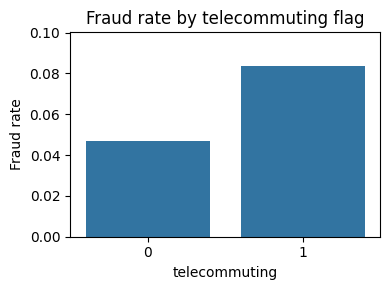

,has_company_logo,fraud_rate
0,0,0.159290
1,1,0.019902


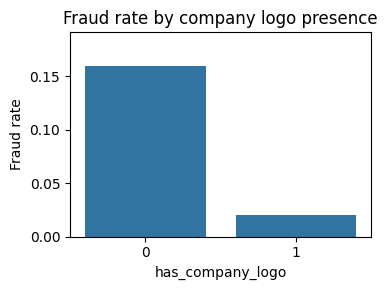

,has_questions,fraud_rate
0,0,0.067782
1,1,0.028435


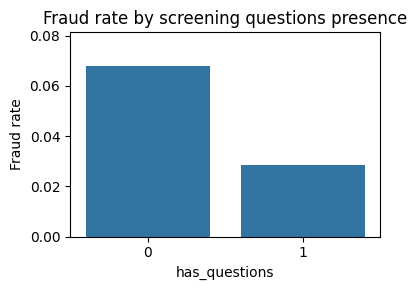

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_fraud_rate_by_flag(flag_col, title):
    # fraud rate = mean of 0/1 target
    data = (
        df.groupby(flag_col)["fraudulent"]
        .mean()
        .reset_index(name="fraud_rate")
    )

    display(data)

    plt.figure(figsize=(4, 3))
    sns.barplot(x=flag_col, y="fraud_rate", data=data)
    plt.ylabel("Fraud rate")
    plt.title(title)
    plt.ylim(0, data["fraud_rate"].max() * 1.2)
    plt.tight_layout()
    plt.show()

# Telecommuting (0 = on‑site, 1 = telecommute)
plot_fraud_rate_by_flag("telecommuting", "Fraud rate by telecommuting flag")

# Company logo
plot_fraud_rate_by_flag("has_company_logo", "Fraud rate by company logo presence")

# Screening questions
plot_fraud_rate_by_flag("has_questions", "Fraud rate by screening questions presence")

- Telecommuting
    - Fraud rate ≈ 4.7% for non‑telecommute (0), ≈ 8.3% for telecommute (1).
    - Remote roles are ~1.8× more likely to be fraudulent.

- Company logo

    - Fraud rate ≈ 16% when there is no company logo (0), ≈ 2–3% when there is a logo (1).
    - Missing logo is a very strong fraud signal.

- Screening questions
    - Fraud rate ≈ 6.8% with no questions (0), ≈ 2.8% when questions are present (1).
    - Scam ads are less likely to include screening questions.


Fraudulent ads tend to have shorter requirements and much shorter or missing company profiles; description lengths are only slightly shorter, with large overlap.

#### Feature Selection based on EDA

1. Company profile–centric features (primary signal)
- EDA suggests that the company profile field is one of the strongest indicators of job authenticity.
- Legitimate job postings typically include detailed company descriptions, while fraudulent postings often omit this field or provide minimal information.

- Selected features:
    - Binary indicator: whether `company_profile` is missing or empty
    - Text length feature: number of characters or words in `company_profile`
    - Binned length feature: short / medium / long company profile

These features capture both presence and depth of company information, which helps distinguish legitimate employers from low-effort scam postings.


2. Complementary NLP features from other text fields

- Textual fields such as `description`, `requirements`, and `title` contain linguistic patterns that differentiate legitimate postings from scams.

- Selected features:
    - TF-IDF vectors from:
        -`description`
        - `requirements`
        - `title`

These capture wording patterns associated with fraudulent ads (e.g., vague roles, urgency, unrealistic compensation).


3. Platform and Metadata Features

- Platform-level attributes provide signals about posting legitimacy.

- Selected binary features:
    - `has_company_logo`
    - `has_questions`
    - `telecommuting`

- EDA shows higher fraud prevalence among postings that:
    - lack company logos
    - lack screening questions
    - advertise remote positions

- Additional structured features:
    - `employment_type`
